# Assignment: Image Segmentation with Different CNN Architectures

Train and compare at least two different CNN-based segmentation models (Simple FCN and a small U-Net-like model) on an image+mask dataset, and visualize their results.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
train_dataset_path = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017"
mask_train_dataset_path = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017"


In [2]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
class ImageMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=128, limit=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size

        self.mask_map = {}
        for m in os.listdir(mask_dir):
            if "_mask" in m:
                key = m.replace("_mask.png", "").replace("_mask.jpg", "")
                self.mask_map[key] = m

        self.image_files = [
            f for f in sorted(os.listdir(image_dir))
            if f.split(".")[0] in self.mask_map
        ]

        if limit:
            self.image_files = self.image_files[:limit]

        print("Images used:", len(self.image_files))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        key = img_name.split(".")[0]

        img = cv2.imread(os.path.join(self.image_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        mask = cv2.imread(os.path.join(self.mask_dir, self.mask_map[key]), 0)
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        img = torch.tensor(img.transpose(2, 0, 1),
                           dtype=torch.float32) / 255.0
        mask = torch.tensor((mask > 127).astype("float32")).unsqueeze(0)

        return img, mask


In [4]:
dataset = ImageMaskDataset(
    train_dataset_path,
    mask_train_dataset_path,
    img_size=128,
    limit=30
)

loader = DataLoader(dataset, batch_size=4, shuffle=True)
print("Dataset size:", len(dataset))



Images used: 30
Dataset size: 30


In [5]:
class BaselineFCN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [6]:
class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.Upsample(scale_factor=2,
                              mode="bilinear",
                              align_corners=True)

        self.decoder = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        enc = self.encoder(x)
        mid = self.bottleneck(self.pool(enc))
        up = self.up(mid)
        x = torch.cat([up, enc], dim=1)
        return self.decoder(x)


In [7]:
def train_segmentation_model(model, dataloader, epochs=3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        epoch_loss = 0.0

        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")


In [8]:
fcn = BaselineFCN()
unet = MiniUNet()

print("Training FCN")
train_segmentation_model(fcn, loader, epochs=1)

print("Training U-Net")
train_segmentation_model(unet, loader, epochs=1)


Training FCN
Epoch 1/1 | Loss: 5.3202
Training U-Net
Epoch 1/1 | Loss: 5.6847


In [9]:
def visualize_predictions(model, dataset, samples=3):
    model.eval()

    for i in range(samples):
        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred = torch.sigmoid(pred).cpu().squeeze().numpy()

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].imshow(img.permute(1, 2, 0))
        ax[0].set_title("Image")

        ax[1].imshow(mask.squeeze(), cmap="gray")
        ax[1].set_title("Ground Truth")

        ax[2].imshow(pred, cmap="gray")
        ax[2].set_title("Prediction")

        for a in ax:
            a.axis("off")

        plt.show()


FCN Predictions


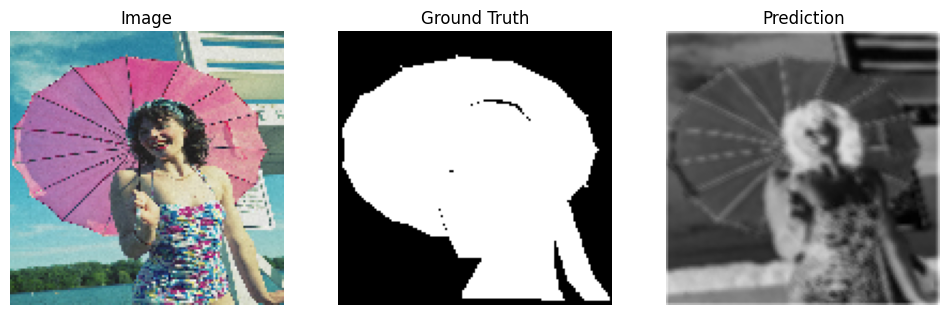

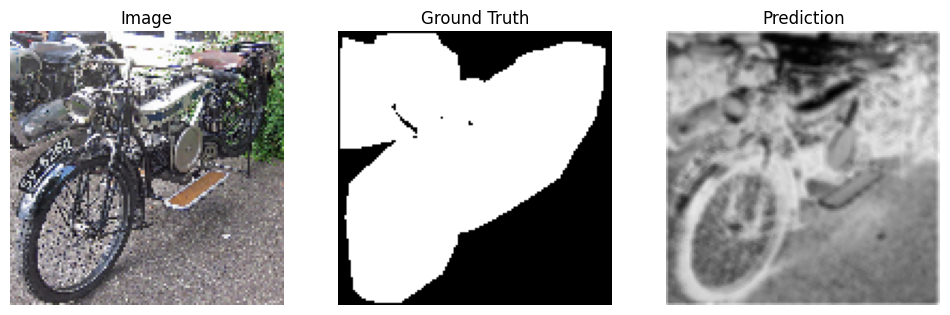

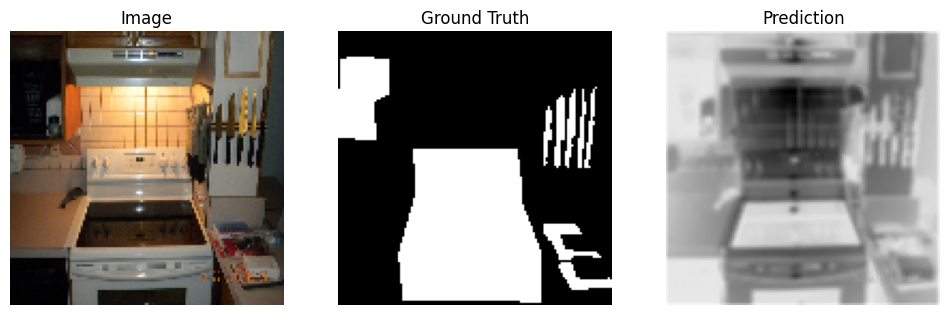

U-Net Predictions


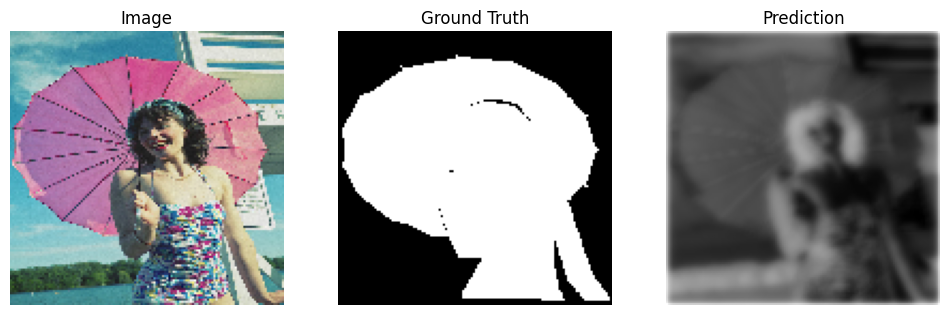

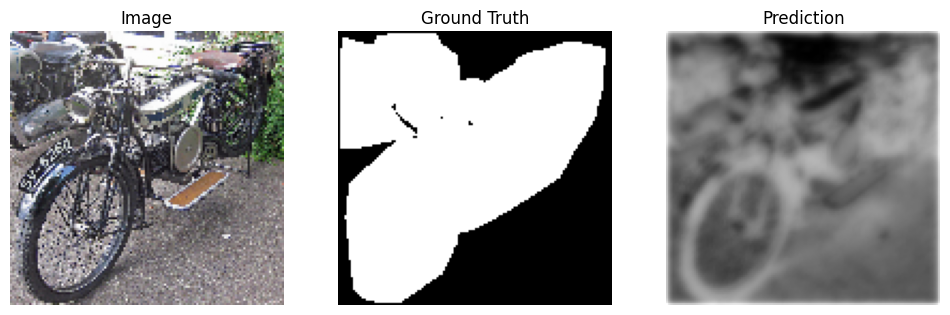

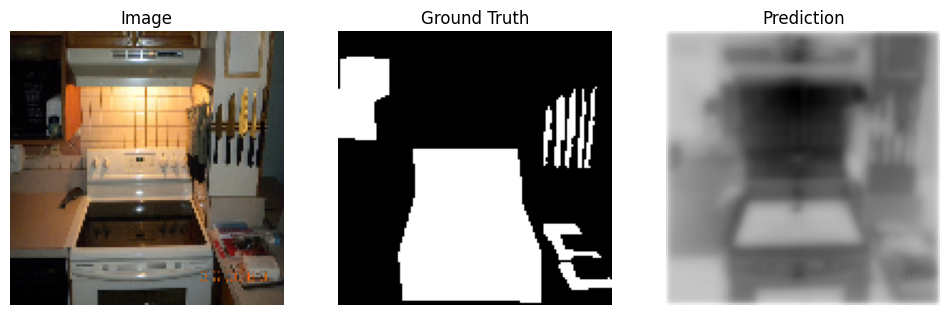

In [11]:
print("FCN Predictions")
visualize_predictions(fcn, dataset)

print("U-Net Predictions")
visualize_predictions(unet, dataset)
